In [ ]:
# 1. Thiết lập thư viện & Khởi tạo cấu hình cấu trúc đồ thị

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from statsmodels.stats.outliers_influence import variance_inflation_factor
from pandas.api.types import is_numeric_dtype

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [ ]:
# 2. Tải dữ liệu & Đồng bộ định dạng số thập phân

In [ ]:
df = pd.read_csv("/content/Emerging_Developing_Markets NEW.csv")

columns_to_convert = [
    'DTD_PB', 'DTC_PB', 'ESGS', 'ESGcom', 'ESGC', 'E', 'S', 'G', 'ETA', 'NPL',
    'CTI', 'TDTA', 'REVDIV', 'LOANGR', 'TA', 'EG', 'INF', 'HHII', 'GOV', 'MIP',
    'REG', 'LNTA', 'E1', 'E2', 'E3', 'S1', 'S2', 'S3', 'S4', 'G1', 'G2', 'G3'
]

for col in columns_to_convert:
    if col in df.columns:
        df[col] = df[col].astype(str).str.replace(',', '.', regex=False).astype(float)

print(f"Initial data shape: {df.shape}")

Initial data shape: (1092, 39)


In [ ]:
# 3. Định vị dữ liệu bảng (Panel Scope) & Lập bảng phân loại biến

In [ ]:
def classify_variable(col, series):
    unique_vals = set(series.dropna().unique())
    if col == 'Bank_ID': return 'Identifier'
    if col == 'Year': return 'Time Identifier'
    if unique_vals.issubset({0, 1}): return 'Dummy / Categorical'
    if is_numeric_dtype(series): return 'Numerical'
    return 'Other'

N = df['Bank_ID'].nunique()
T = df['Year'].nunique()
print(f"Number of banks (N): {N}\nNumber of years (T): {T}\nExpected observations (N x T): {N * T}\nActual observations: {len(df)}")

variable_type_table = pd.DataFrame({
    'Variable': df.columns,
    'Pandas dtype': df.dtypes.astype(str).values,
    'Unique Values': [df[col].nunique() for col in df.columns],
    'Variable Type': [classify_variable(col, df[col]) for col in df.columns]
})
display(variable_type_table)

Number of banks (N): 156
Number of years (T): 7
Expected observations (N x T): 1092
Actual observations: 1092


,Variable,Pandas dtype,Unique Values,Variable Type
0,No,int64,1092,Numerical
1,Year,int64,7,Time Identifier
2,Country_ID,int64,27,Numerical
3,Bank_ID,int64,156,Identifier
4,IB,int64,2,Dummy / Categorical
5,DTD_PB,float64,975,Numerical
6,DTC_PB,float64,976,Numerical
7,ESGS,float64,864,Numerical
8,ESGcom,float64,868,Numerical
9,ESGC,float64,43,Numerical


In [ ]:
# 4. Xử lý dữ liệu khuyết thiếu bằng thuật toán MICE

In [ ]:
# 1. Xác định các cột bị thiếu dữ liệu ban đầu
missing_numeric_cols = df[columns_to_convert].isnull().sum()
missing_numeric_cols = missing_numeric_cols[missing_numeric_cols > 0].index.tolist()

print("=== TÌNH TRẠNG DỮ LIỆU BAN ĐẦU (TRƯỚC KHI ĐIỀN KHUYẾT MICE) ===")
print("Số lượng ô trống chi tiết ở các cột ban đầu bị thiếu:")
display(df[missing_numeric_cols].isnull().sum())

# 2. Tiến hành sao chép và điền khuyết bằng MICE
df_imputed = df.copy()
imputer = IterativeImputer(random_state=42, max_iter=10)
df_imputed[missing_numeric_cols] = imputer.fit_transform(df_imputed[missing_numeric_cols])

# 3. Định dạng lại cột Năm
df_imputed['Year'] = df_imputed['Year'].astype(int)

print("\n=== KIỂM TRA TÌNH TRẠNG DỮ LIỆU SAU KHI ĐIỀN KHUYẾT (MICE) ===")

# Cách 1: Tính toán tổng số ô missing trên TOÀN BỘ bảng dữ liệu (Mong muốn bằng 0)
tong_o_trong_con_lai = df_imputed.isnull().sum().sum()
print(f"Tổng số ô trống còn sót lại trên toàn bảng df_imputed: {tong_o_trong_con_lai}")

# Cách 2: Hiển thị bảng kiểm tra chi tiết từng cột để giảng viên đối chiếu
print("\nSố lượng ô trống chi tiết ở các cột ban đầu bị thiếu:")
display(df_imputed[missing_numeric_cols].isnull().sum())

=== TÌNH TRẠNG DỮ LIỆU BAN ĐẦU (TRƯỚC KHI ĐIỀN KHUYẾT MICE) ===
Số lượng ô trống chi tiết ở các cột ban đầu bị thiếu:


,0
DTD_PB,78
DTC_PB,78
ESGS,143
ESGcom,143
ESGC,143
E,143
S,143
G,143
ETA,5
NPL,19



=== KIỂM TRA TÌNH TRẠNG DỮ LIỆU SAU KHI ĐIỀN KHUYẾT (MICE) ===
Tổng số ô trống còn sót lại trên toàn bảng df_imputed: 0

Số lượng ô trống chi tiết ở các cột ban đầu bị thiếu:


,0
DTD_PB,0
DTC_PB,0
ESGS,0
ESGcom,0
ESGC,0
E,0
S,0
G,0
ETA,0
NPL,0


In [ ]:
# 5. Kiểm tra tính dừng dữ liệu bảng (Panel Unit Root Test)

In [ ]:
!pip install arch

from arch.unitroot import ADF
from arch.utility.exceptions import InfeasibleTestException

print("Kết quả thống kê tính dừng ADF cho toàn bộ các ngân hàng: ")
so_luong_khong_dung = 0
so_luong_dung = 0
so_luong_loi_he_so = 0
tong_so_bank = df_imputed['Bank_ID'].nunique()

for bank in df_imputed['Bank_ID'].unique():
    npl_series = df_imputed[df_imputed['Bank_ID'] == bank]['NPL'].dropna()

    # Kiểm tra điều kiện chuỗi thời gian tối thiểu để chạy Dickey-Fuller
    if len(npl_series) >= 5:
        try:
            # Ép tham số lags=0 để xử lý triệt để lỗi thiếu bậc tự do trên chuỗi thời gian ngắn (T=7)
            adf = ADF(npl_series, lags=0)

            if adf.pvalue > 0.05:
                so_luong_khong_dung += 1
            else:
                so_luong_dung += 1
        except (InfeasibleTestException, ValueError):
            # Xử lý các trường hợp chuỗi số bị đứng im không biến động (locally constant)
            so_luong_loi_he_so += 1
    else:
        so_luong_loi_he_so += 1

print(f"Tổng số ngân hàng trong mẫu: {tong_so_bank}")
print(f"Số ngân hàng có chuỗi NPL KHÔNG DỪNG (p-value > 0.05): {so_luong_khong_dung} ({so_luong_khong_dung / tong_so_bank * 100:.2f}%)")
print(f"Số ngân hàng có chuỗi NPL DỪNG (p-value <= 0.05): {so_luong_dung} ({so_luong_dung / tong_so_bank * 100:.2f}%)")
print(f"Số ngân hàng không đủ điều kiện kiểm định (Dữ liệu không biến động/Quá ngắn): {so_luong_loi_he_so} ({so_luong_loi_he_so / tong_so_bank * 100:.2f}%)")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 15.6 MB/s eta 0:00:00
Kết quả thống kê tính dừng ADF cho toàn bộ các ngân hàng: 
Tổng số ngân hàng trong mẫu: 156
Số ngân hàng có chuỗi NPL KHÔNG DỪNG (p-value > 0.05): 139 (89.10%)
Số ngân hàng có chuỗi NPL DỪNG (p-value <= 0.05): 16 (10.26%)
Số ngân hàng không đủ điều kiện kiểm định (Dữ liệu không biến động/Quá ngắn): 1 (0.64%)


In [ ]:
# 6. Phân tích tương quan chuỗi độ trễ (Lagged Dependent Variable Test)

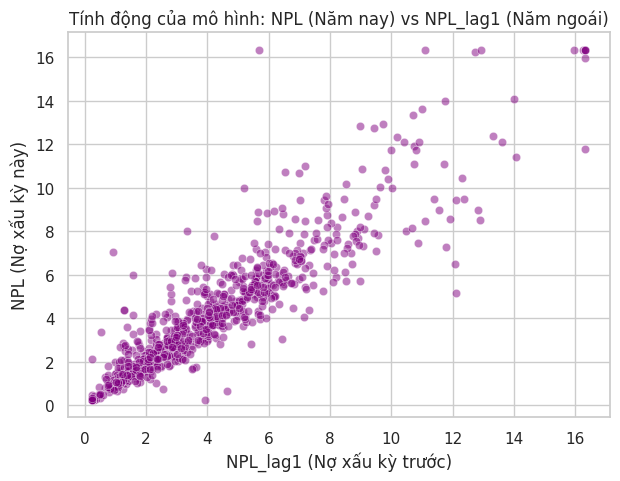

In [ ]:
plt.figure(figsize=(7, 5))

# Tạo biến NPL trễ 1 thời kỳ (NPL_lag1) theo từng Ngân hàng
df_imputed['NPL_lag1'] = df_imputed.groupby('Bank_ID')['NPL'].shift(1)

# Vẽ biểu đồ phân tán giữa NPL năm nay và NPL năm ngoái để chứng minh tính động (Dynamic)
sns.scatterplot(data=df_imputed, x='NPL_lag1', y='NPL', alpha=0.5, color='purple')
plt.title('Tính động của mô hình: NPL (Năm nay) vs NPL_lag1 (Năm ngoái)')
plt.xlabel('NPL_lag1 (Nợ xấu kỳ trước)')
plt.ylabel('NPL (Nợ xấu kỳ này)')
plt.show()

In [ ]:
# 7. Kiểm tra đa cộng tuyến VIF & Phân tích Ma trận tương quan (Heatmap)

--- Variance Inflation Factor (VIF) Results ---


,Variable,VIF
0,const,617.927082
1,ESGS,1.288460
2,ETA,2.046556
3,CTI,1.300589
4,TDTA,2.009954
5,REVDIV,2.963079
6,LOANGR,1.152181
7,LNTA,1.563570
8,EG,1.197075
9,INF,1.540208


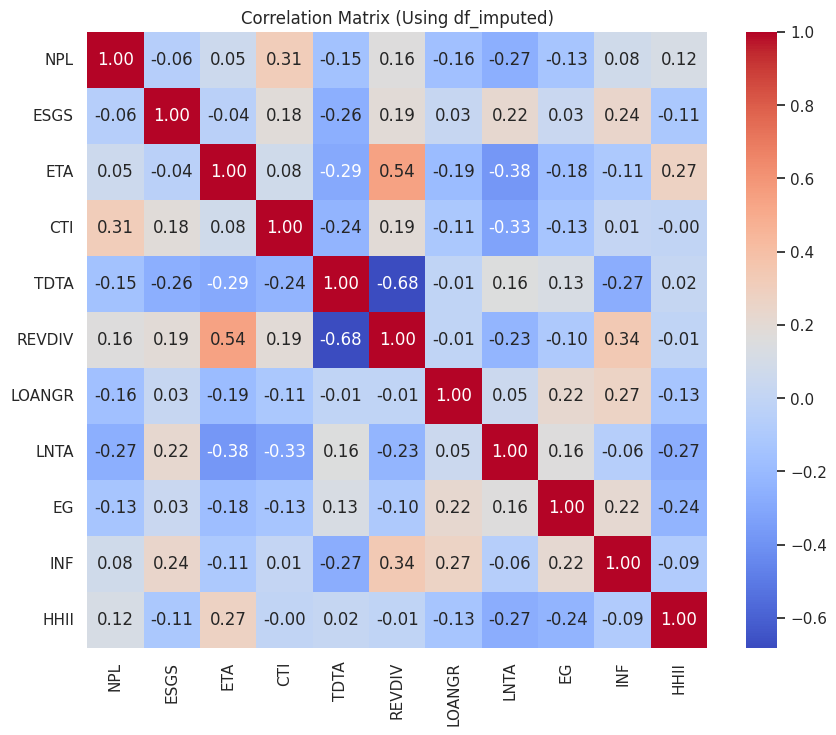

In [ ]:
# 7a. Hệ số VIF phóng đại đa cộng tuyến
model_vars_vif = ['ESGS', 'ETA', 'CTI', 'TDTA', 'REVDIV', 'LOANGR', 'LNTA', 'EG', 'INF', 'HHII']
X = df_imputed[model_vars_vif]
X = sm.add_constant(X)

vif = pd.DataFrame()
vif["Variable"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print("--- Variance Inflation Factor (VIF) Results ---")
display(vif)

# 7b. Đồ thị Ma trận tương quan
plt.figure(figsize=(10, 8))
corr_vars = ['NPL'] + model_vars_vif
sns.heatmap(df_imputed[corr_vars].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix (Using df_imputed)')
plt.show()

In [ ]:
# 8. Phân tích đồ thị phân tán (Scatter Plot) giữa Biến phụ thuộc và Biến độc lập

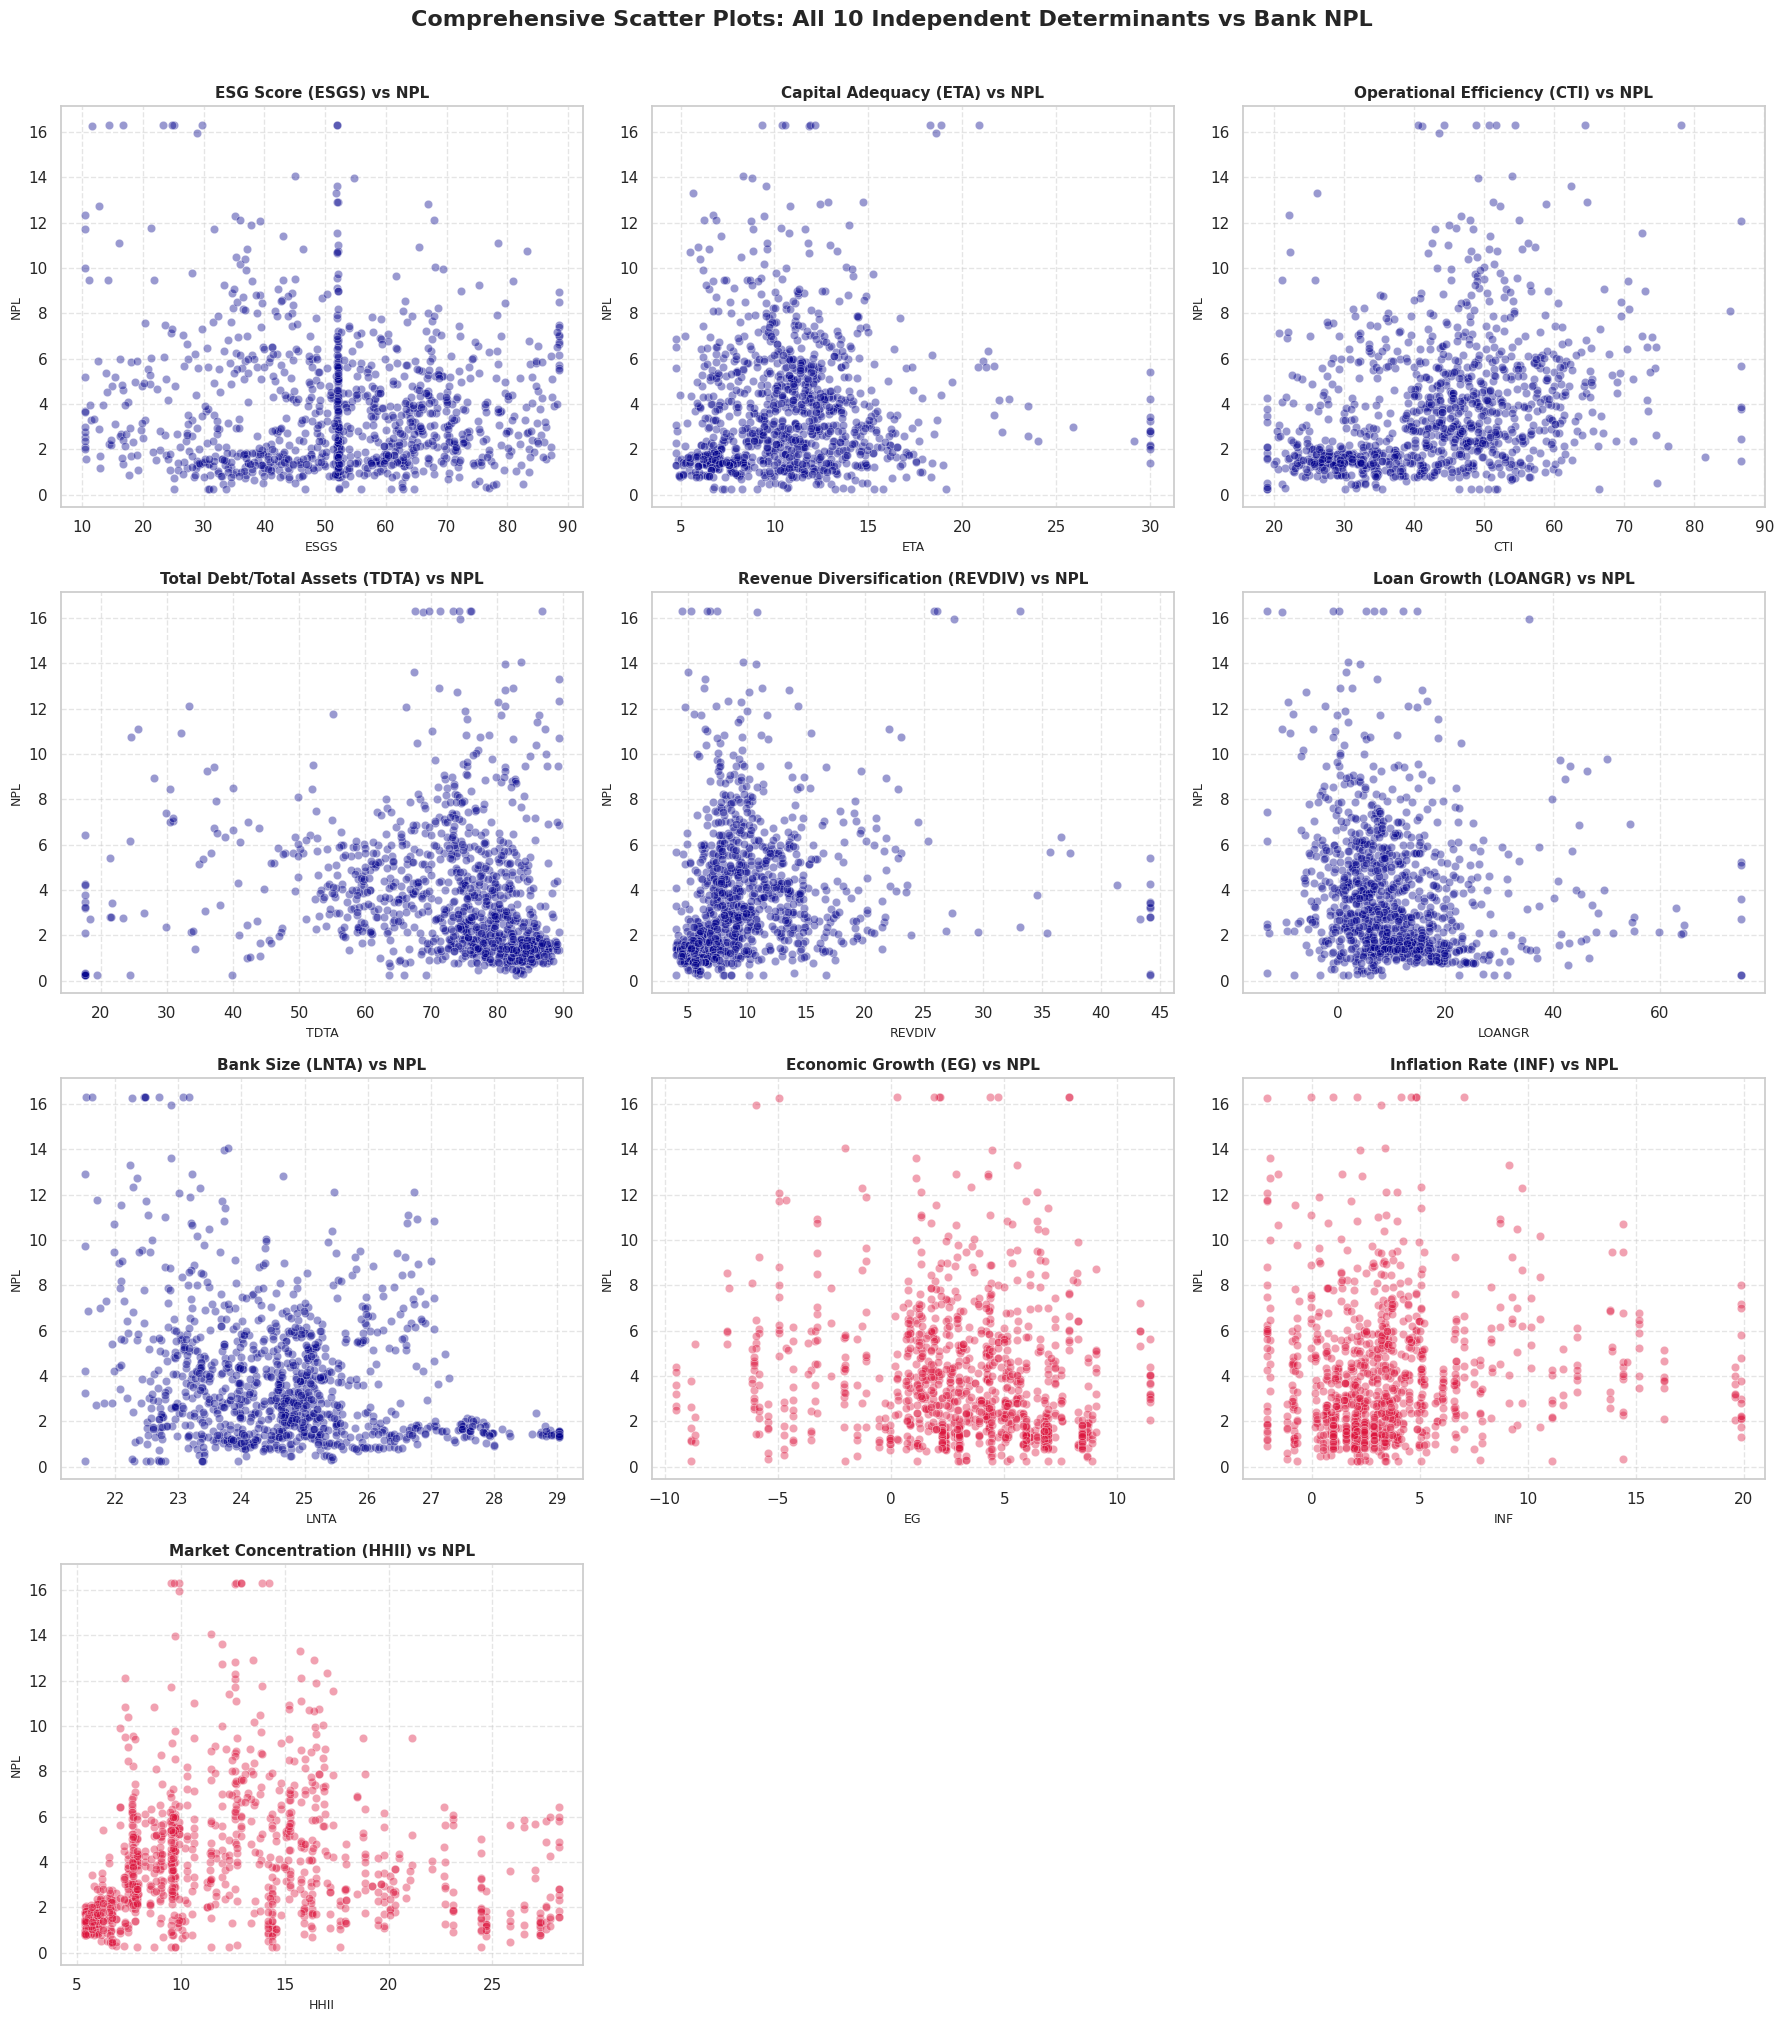

In [ ]:
# Danh sách 10 biến độc lập:
all_10_vars = ['ESGS', 'ETA', 'CTI', 'TDTA', 'REVDIV', 'LOANGR', 'LNTA', 'EG', 'INF', 'HHII']

titles_10 = [
    'ESG Score (ESGS)', 'Capital Adequacy (ETA)', 'Operational Efficiency (CTI)',
    'Total Debt/Total Assets (TDTA)', 'Revenue Diversification (REVDIV)', 'Loan Growth (LOANGR)',
    'Bank Size (LNTA)', 'Economic Growth (EG)', 'Inflation Rate (INF)', 'Market Concentration (HHII)'
]

# Khởi tạo ma trận hiển thị kích thước 4 hàng, 3 cột để chứa đủ 10 hình vẽ
fig, axes = plt.subplots(4, 3, figsize=(18, 20))
axes = axes.flatten()

for idx, var in enumerate(all_10_vars):
    # Sử dụng màu sắc phân biệt giữa biến vi mô ngân hàng và biến vĩ mô/thị trường
    plot_color = 'darkblue' if idx < 7 else 'crimson'

    sns.scatterplot(data=df_imputed, x=var, y='NPL', alpha=0.4, ax=axes[idx], color=plot_color)
    axes[idx].set_title(f'{titles_10[idx]} vs NPL', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel(var, fontsize=9)
    axes[idx].set_ylabel('NPL', fontsize=9)
    axes[idx].grid(True, linestyle='--', alpha=0.5)

# Ẩn đi 2 ô trống thừa cuối cùng ở góc phải bên dưới của lưới 4x3 (vị trí index 10 và 11)
for empty_idx in range(len(all_10_vars), len(axes)):
    fig.delaxes(axes[empty_idx])

plt.suptitle('Comprehensive Scatter Plots: All 10 Independent Determinants vs Bank NPL', fontsize=16, y=1.01, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# 9. Thống kê mô tả

In [ ]:
# Xác định chính xác 11 biến đưa vào mô hình SGMM
model_vars = ['NPL', 'ESGS', 'ETA', 'CTI', 'TDTA', 'REVDIV', 'LOANGR', 'LNTA', 'EG', 'INF', 'HHII']
df_model = df_imputed[model_vars].copy()
print('DESCRIPTIVE STATISTICS: ')

Bang_TKMT = df_model.describe().T

Bang_TKMT.columns = ['Count', 'Mean', 'Std', 'Min', '25%', '50%', '75%', 'Max']
display(Bang_TKMT)

print(f"\nKích thước ma trận dữ liệu nộp hồi quy SGMM: {df_model.shape}")

DESCRIPTIVE STATISTICS: 


,Count,Mean,Std,Min,25%,50%,75%,Max
NPL,1092.0,3.844644,2.874599,0.250000,1.640000,3.020000,5.292500,16.330000
ESGS,1092.0,52.099026,17.870727,10.420000,40.182500,52.133170,64.605000,88.540000
ETA,1092.0,10.792398,3.875278,4.740973,7.948264,10.580167,12.607397,29.983417
CTI,1092.0,43.540186,12.697978,18.930000,33.440000,44.000000,51.642500,86.650000
TDTA,1092.0,72.156666,14.218892,17.574467,66.565225,75.896341,82.083485,89.355478
REVDIV,1092.0,10.207899,5.894785,3.981827,6.546274,8.780358,11.997473,44.125870
LOANGR,1092.0,10.674172,11.841454,-13.390000,3.777500,8.580000,15.062500,75.120000
LNTA,1092.0,24.690782,1.520446,21.521350,23.609398,24.638735,25.423372,29.027750
EG,1092.0,3.081432,3.942941,-9.518295,1.313914,3.297641,5.945208,11.439385
INF,1092.0,3.623866,4.005080,-2.093333,1.593136,2.811841,4.470367,19.873860



Kích thước ma trận dữ liệu nộp hồi quy SGMM: (1092, 11)


In [ ]:
# 10. Trích xuất tập dữ liệu cuối cùng cho mô hình hồi quy

In [ ]:
model_vars = ['NPL', 'ESGS', 'ETA', 'CTI', 'TDTA', 'REVDIV', 'LOANGR', 'LNTA', 'EG', 'INF', 'HHII']
df_model = df_imputed[model_vars].copy()
print(f"Final Model Dataset Shape: {df_model.shape}")
display(df_model.head())

Final Model Dataset Shape: (1092, 11)


,NPL,ESGS,ETA,CTI,TDTA,REVDIV,LOANGR,LNTA,EG,INF,HHII
0,3.68,10.42,11.386605,26.32,75.895594,8.580887,17.85,24.58701,5.561491,1.617488,7.683712
1,3.31,11.45,10.386231,31.02,78.161930,8.319542,15.38,24.75674,0.735069,1.966826,10.277720
2,3.34,11.92,11.972656,27.68,75.491255,8.578705,8.20,24.83262,1.313914,3.068634,10.643510
3,3.97,13.36,12.210888,26.56,74.878514,9.568642,4.34,24.86825,1.108348,-1.931081,11.959530
4,5.88,12.59,10.772716,36.66,75.778406,7.913185,30.64,25.09074,-4.957052,-2.079403,12.582000


Dependent Variable ($y_{it}$): NPL (Non-Performing Loans). Measures institutional credit risk.

Lagged Dependent Variable ($y_{it-1}$): NPL_lag1. Automatically captured to control for the path-dependency of toxic assets. It is instrumented using lagged levels in the difference equation and lagged differences in the levels equation.

Main Explanatory Regressor: ESGS (ESG Score). The primary variable used for hypothesis testing. Treated as endogenous to account for potential resource-allocation feedback loops.

Endogenous Controls ($\mathbf{Bank}_{it}$): ETA, CTI, TDTA, REVDIV, and LOANGR. Micro-level banking indicators prone to reverse causality (e.g., high defaults force shifts in loan growth and capital structures). Instrumented using historical lags ($t-2$ and deeper).

Strictly Exogenous Controls ($\mathbf{Macro}_{it}$): LNTA, EG, and INF. Sticky institutional filters and macroeconomic indicators determined outside the bank's operational boundaries, satisfying the strict orthogonal condition $E[\mathbf{Macro}_{it}\nu_{is}] = 0 \ \forall \ t,s$.

In [ ]:
output_filename = 'cleaned_emerging_developing_markets.csv'
df_imputed.to_csv(output_filename, index=False)

print(f"Data saved to '{output_filename}'")

# To download the file to your local machine (optional, run in a separate cell if needed)
from google.colab import files
files.download(output_filename)

Data saved to 'cleaned_emerging_developing_markets.csv'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>